Do all Exploratory Data Analysis (EDA) in this notebook file
1. Read data

In [1]:
import os
import pandas as pd
from online_retail.utils.base_funcs import load_data

path = os.getcwd()
file_path = os.path.abspath(
    os.path.join(path, '..','..','data/online_retail_II.xlsx'))
data = load_data(file_path=file_path)
data.rename(columns = {'Customer ID':'CustomerID'}, inplace = True)
data.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


Retail data has 8 features. Info about the data is also provided in following parts:

In [2]:
print(data.columns)
data.head()

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'CustomerID', 'Country'],
      dtype='object')


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   CustomerID   417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
CustomerID     107927
Country             0
dtype: int64

Some stocks does not have description. Some customers bought as a guest so they do not have customer ID. Use SQLite to write queries. At first, I want to see whether the Price column is the unit price or is Quantity * U-price. For that, I write a query for just one Stock, within a limited time, to see if we get different values or not. 
Some Quantities are negative which shows it is return objects or canceled (the invoice starts with C). For the same Stock number, the value is different. I guess it contains some charges like shipment. For those that the price is lower, we can say it may contians some discount. I guess we can consider the mode value for the true value of the Stock. At the end, I think it is the price column shows the unit price.

In [4]:
import pandasql as psql

query = '''
SELECT *
FROM data
WHERE StockCode = '85048'
AND InvoiceDate BETWEEN '2009-12-01' AND '2010-02-01'
ORDER BY Country
'''

result = psql.sqldf(query, locals())
result.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,492746,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,4,2009-12-18 13:01:00.000000,7.95,NaN,EIRE
1,492761,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,8,2009-12-18 14:22:00.000000,7.95,14911.0,EIRE
2,C493859,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,-4,2010-01-07 16:15:00.000000,7.95,14911.0,EIRE
3,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00.000000,6.95,13085.0,United Kingdom
4,C489518,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,-1,2009-12-01 11:35:00.000000,7.95,15461.0,United Kingdom


Let us do RFM analysis.<br>
R -> Recency: How recently a customer made their last purchase -> more engaged and more likely to buy again.<br>
F -> Frequecy: How often a customer purchase -> Loyal customers.<br>
M -> Monetary: How much they spent -> spend a lot have more value.<br>
This is a study that is used for customer segmentation technique. The goal is to quantify customer value and behavior. So using these three criteria, we can segment our customers into 5 categories.<br>
1. Champions -> High RFM -> loyal and active.<br>
2. Loyal -> High F but regular M -> Regular customer.<br>
3. Big Spenders -> High M low F -> High value but occasional<br>
4. At Risk -> Used to buy but not now -> At risk for churn<br>
5. Lost -> Have not purchased for a long time.<br>

Let us write different querie to make the table for RFM. First of all, let us remove all the customers with null customer ID and return transactions as well. Retrun transactions start with 'C' in their invoice number. 

In [5]:
query = '''
SELECT *
FROM data
WHERE CustomerID IS NOT NULL AND Invoice NOT LIKE 'C%'
'''
data_clean = psql.sqldf(query, locals())
data_clean.info()
data_clean.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407695 entries, 0 to 407694
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      407695 non-null  object 
 1   StockCode    407695 non-null  object 
 2   Description  407695 non-null  object 
 3   Quantity     407695 non-null  int64  
 4   InvoiceDate  407695 non-null  object 
 5   Price        407695 non-null  float64
 6   CustomerID   407695 non-null  float64
 7   Country      407695 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 24.9+ MB


Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
CustomerID     0
Country        0
dtype: int64

Now isnull().sum() is zero. Let us GROUP BY customer and find the difference between the last transaction of each customer and snapshot_data (The day that whole table is extracted).

In [6]:
query = '''
WITH temp_1 AS(
SELECT MAX(InvoiceDate) as snapshot_date
FROM data_clean
LIMIT 1
), temp_2 AS (
SELECT CustomerID, MAX(InvoiceDate) as latest_purchase_date
FROM data_clean
GROUP BY CustomerID
)
SELECT t2.CustomerID, t2.latest_purchase_date, t1.snapshot_date,
         ROUND(julianday(t1.snapshot_date) - julianday(t2.latest_purchase_date),0) AS Recency_Days
FROM temp_2 t2
CROSS JOIN temp_1 t1
'''

R = psql.sqldf(query, locals())
R.head()

,CustomerID,latest_purchase_date,snapshot_date,Recency_Days
0,12346.0,2010-06-28 13:53:00.000000,2010-12-09 20:01:00.000000,164.0
1,12347.0,2010-12-07 14:57:00.000000,2010-12-09 20:01:00.000000,2.0
2,12348.0,2010-09-27 14:59:00.000000,2010-12-09 20:01:00.000000,73.0
3,12349.0,2010-10-28 08:23:00.000000,2010-12-09 20:01:00.000000,42.0
4,12351.0,2010-11-29 15:23:00.000000,2010-12-09 20:01:00.000000,10.0


In table R, we have Recency information, which is difference between last transaction of each customer and when we had snapshot from our data. Next we make the table for the Frequency, F, which is number of distinct purchases a customer made in the window analysis.

In [7]:
query = '''
SELECT CustomerID, Count(DISTINCT Invoice) AS Frequency
FROM data_clean
GROUP BY CustomerID
'''

F = psql.sqldf(query, locals())
F.head()

,CustomerID,Frequency
0,12346.0,11
1,12347.0,2
2,12348.0,1
3,12349.0,3
4,12351.0,1


At the end, we want to generate Monetary table, M, which is the total amount of money spent by each customer.

In [8]:
query = '''
SELECT CustomerID, SUM(Quantity*Price) AS Monetary
FROM data_clean
GROUP BY CustomerID
'''
M = psql.sqldf(query, locals())

M.head()

,CustomerID,Monetary
0,12346.0,372.86
1,12347.0,1323.32
2,12348.0,222.16
3,12349.0,2671.14
4,12351.0,300.93


The final RMF table is:

In [9]:
query = '''
SELECT R.CustomerID, R.Recency_Days, F.Frequency, M.Monetary
FROM R AS R
INNER JOIN F AS F ON R.CustomerID = F.CustomerID
INNER JOIN M AS M ON R.CustomerID = M.CustomerID
'''
RMF = psql.sqldf(query, locals())
RMF.head()

,CustomerID,Recency_Days,Frequency,Monetary
0,12346.0,164.0,11,372.86
1,12347.0,2.0,2,1323.32
2,12348.0,73.0,1,222.16
3,12349.0,42.0,3,2671.14
4,12351.0,10.0,1,300.93


## Statistical analysis:
In this section, I do the hist analysis, and joint plot of each RMF feature.

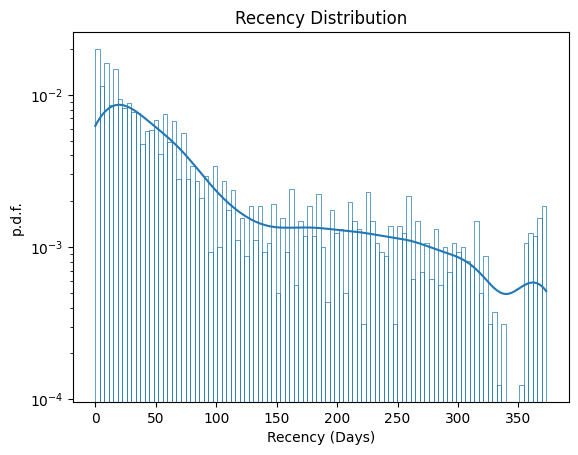

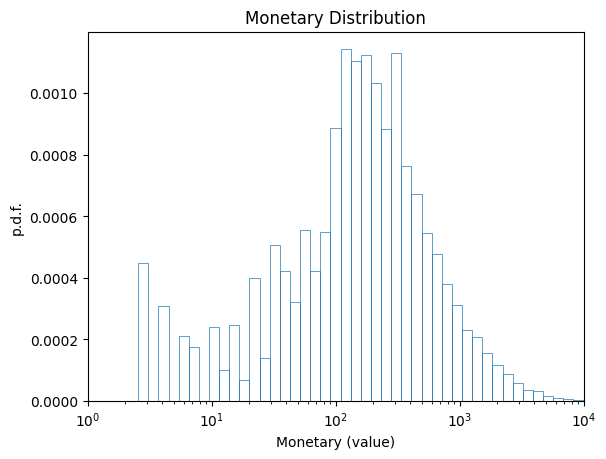

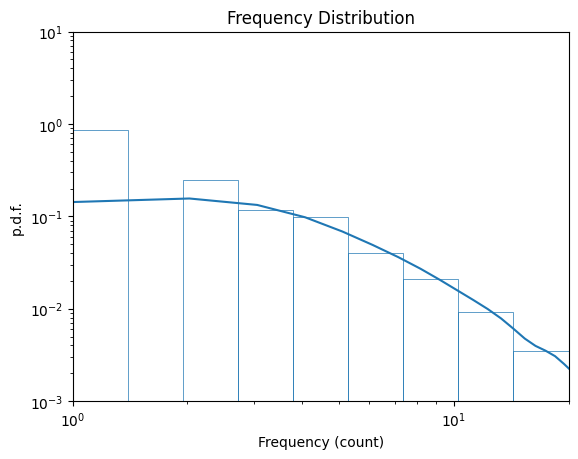

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.histplot(data = RMF, x = 'Recency_Days', fill=False, bins=100, stat = 'density', kde=True)
plt.title('Recency Distribution')
plt.yscale('log')
plt.xlabel('Recency (Days)')
plt.ylabel('p.d.f.')
plt.show()

xmin, xmax = 1e0, 1e4
bins = np.logspace(np.log10(xmin), np.log10(xmax), 50)
sns.histplot(data = RMF, x = 'Monetary', fill=False, bins=bins, stat = 'density')
plt.title('Monetary Distribution')
plt.xscale('log')
plt.xlabel('Monetary (value)')
plt.ylabel('p.d.f.')
plt.xlim(xmin, xmax)
plt.show()

xmin, xmax = 1e0, 2e1
bins = np.logspace(np.log10(xmin), np.log10(xmax), 10)
sns.histplot(data = RMF, x = 'Frequency', fill=False, bins=bins, stat = 'density', kde=True)
plt.title('Frequency Distribution')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (count)')
plt.ylabel('p.d.f.')    
plt.xlim(xmin, xmax)
plt.ylim(1e-3, 1e1)
plt.show()

Recency has exponential distribution `log(y)=mx+b`, Monetry has log-normal distribution `log(x) ~ N`, and Frequency has power-law distribution `log(y) = mlog(x)+b`. In the following section, I will plot the joint scatter plot of these distributions.

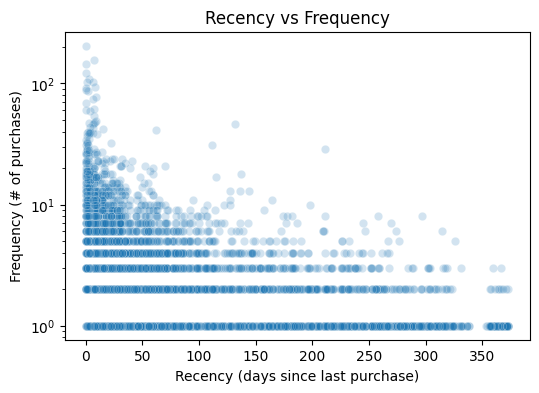

In [11]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=RMF, x='Recency_Days', y='Frequency', alpha=0.2)
plt.xscale('linear')
plt.yscale('log')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Frequency (# of purchases)')
plt.title('Recency vs Frequency')
plt.show()

In [12]:
query = '''
SELECT sum(CASE WHEN Recency_Days > 100 AND Frequency < 3 THEN 1 ELSE 0 END)*1.0 / COUNT(*) AS ratio_not_active
FROM RMF
'''

ratio_not_active = psql.sqldf(query, locals())
print(ratio_not_active)

   ratio_not_active
0          0.241076


Around 24% of the whole customers had less than 3 transaction in the last 100 days. 

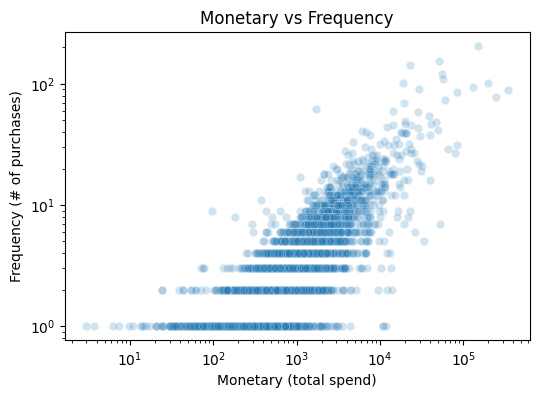

In [13]:
plt.figure(figsize=(6,4))
sns.scatterplot(data = RMF, x='Monetary', y='Frequency', alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Monetary (total spend)')
plt.ylabel('Frequency (# of purchases)')
plt.title('Monetary vs Frequency')
plt.show()

In [14]:
query = '''
SELECT sum(CASE WHEN Monetary >= 1000 AND Frequency >= 2 THEN 1 ELSE 0 END)*1.0/COUNT(*) AS ratio_high_value
FROM RMF
'''
ratio_high_value = psql.sqldf(query, locals())
print(ratio_high_value)

   ratio_high_value
0          0.385257


38% of customers who had spent more than 1000$, had more than two transactions. So there is a positive correlation between monetary and frequency.

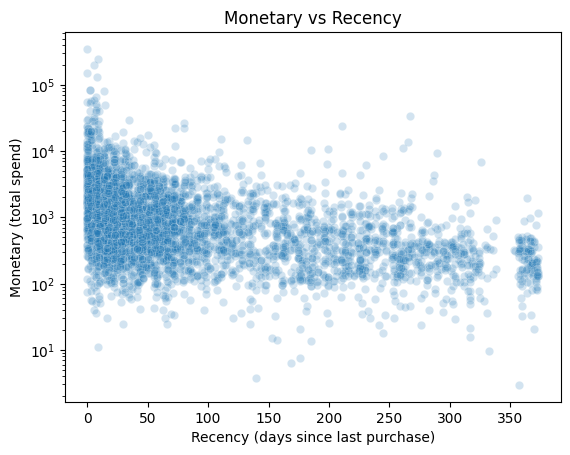

In [15]:
sns.scatterplot(data = RMF, x='Recency_Days', y='Monetary', alpha=0.2)
plt.xscale('linear')
plt.yscale('log')
plt.ylabel('Monetary (total spend)')
plt.xlabel('Recency (days since last purchase)')
plt.title('Monetary vs Recency')
plt.show()

There is no positive correlation between Monetary and Recency. Let us plot the correlation matrix

In [16]:
rmf_corr = RMF[['Recency_Days', 'Frequency', 'Monetary']].corr(method='pearson')
print(rmf_corr)

              Recency_Days  Frequency  Monetary
Recency_Days      1.000000  -0.248930 -0.121212
Frequency        -0.248930   1.000000  0.656273
Monetary         -0.121212   0.656273  1.000000


The only evident correlation is between Frequency and Monetary. Having the RMF, we can do behavioral segmentation, which has been done in the file cust_seg.ipynb

In [17]:
RMF.to_csv('RMF_table.csv', index=False)